In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from xgboost import XGBRegressor
import optuna
import statsmodels.api as sm

In [2]:
# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('data.csv', encoding='utf-8')

In [3]:
# 5대 리그 필터링
top_5_leagues = ['Bundesliga', 'LaLiga', 'Premier League', 'Serie A', 'Ligue 1']
df = df[df['리그'].isin(top_5_leagues)].copy()

# 기본 전처리
df['TM_시장가치_EUR'] = pd.to_numeric(df['TM_시장가치_EUR'], errors='coerce')
df.dropna(subset=['TM_시장가치_EUR', '포지션'], inplace=True)
df = df[df['TM_시장가치_EUR'] > 0]
df = df[df['포지션'] != '골키퍼'].copy()


# 2. 피쳐 엔지니어링 (Feature Engineering)
df.sort_values(by=['name_key', '시즌'], inplace=True)
df['나이_제곱'] = df['시즌종료시점만나이'] ** 2

stats_for_change = ['득점', '어시스트', '기회 창출', '슛', '태클 성공', '가로채기', '터치', '성공한 패스']

for stat in stats_for_change:
    df[f'전시즌_{stat}'] = df.groupby('name_key')[stat].shift(1).fillna(0)
    df[f'{stat}_변화량'] = df[stat] - df[f'전시즌_{stat}']

df['나이x득점_변화량'] = (df['시즌종료시점만나이'] * df['득점_변화량'])
df['슛_대비_득점율'] = np.divide(df['득점'], df['슛'], out=np.zeros_like(df['득점'], dtype=float), where=df['슛']!=0)

df['전시즌_시장가치_EUR'] = df.groupby('name_key')['TM_시장가치_EUR'].shift(1).fillna(0)
df['log_전시즌_시장가치'] = np.log1p(df['전시즌_시장가치_EUR'])
df['log_현재_시장가치'] = np.log1p(df['TM_시장가치_EUR'])
df['시장가치_변화량'] = df['TM_시장가치_EUR'] - df['전시즌_시장가치_EUR']

In [4]:
# 3. 포지션 그룹핑
def group_position_detailed(pos):
    pos_str = str(pos)
    if '중앙 수비수' in pos_str: return '중앙 수비수'
    if '왼쪽 수비수' in pos_str or '오른쪽 수비수' in pos_str: return '측면 수비수'
    if '수비형 미드필더' in pos_str: return '수비형 미드필더'
    if '공격형 미드필더' in pos_str: return '공격형 미드필더'
    if '중앙 미드필더' in pos_str: return '중앙 미드필더'
    if '윙어' in pos_str or '왼쪽 미드필더' in pos_str or '오른쪽 미드필더' in pos_str: return '윙어'
    if '스트라이커' in pos_str: return '스트라이커'
    return '기타'
df['포지션_그룹'] = df['포지션'].apply(group_position_detailed)
df = df[df['포지션_그룹'] != '기타']

In [ ]:
best_params_per_position = {
    '공격형 미드필더': {'n_estimators': 1300, 'learning_rate': 0.043046501045109875, 'max_depth': 12, 'subsample': 0.7146481658848329, 'colsample_bytree': 0.5868849207152588, 'reg_alpha': 0.9632756396268152, 'reg_lambda': 0.0003821877960217409},
    '수비형 미드필더': {'n_estimators': 1200, 'learning_rate': 0.04380824140046239, 'max_depth': 17, 'subsample': 0.3847060064183181, 'colsample_bytree': 0.4127967809883891, 'reg_alpha': 0.014734131067062008, 'reg_lambda': 1.9694184672233443e-05},
    '스트라이커': {'n_estimators': 1100, 'learning_rate': 0.0376632474408951, 'max_depth': 15, 'subsample': 0.6268242620148625, 'colsample_bytree': 0.2985317568222804, 'reg_alpha': 1.3203548526180334e-06, 'reg_lambda': 0.0008133122545807272},
    '윙어': {'n_estimators': 1500, 'learning_rate': 0.07284, 'max_depth': 13, 'subsample': 0.9931, 'colsample_bytree': 0.2543, 'reg_alpha': 7.460e-06, 'reg_lambda': 5.387e-06}, # 2차 결과
    '중앙 미드필더': {'n_estimators': 1600, 'learning_rate': 0.07079413461238956, 'max_depth': 8, 'subsample': 0.8327918966197049, 'colsample_bytree': 0.580856531512097, 'reg_alpha': 3.0326869119156524e-05, 'reg_lambda': 0.0844581233820778}, # 2차 결과
    '중앙 수비수': {'n_estimators': 1500, 'learning_rate': 0.028101536180308466, 'max_depth': 9, 'subsample': 0.39591894623275053, 'colsample_bytree': 0.1690295563927809, 'reg_alpha': 0.8214238173442158, 'reg_lambda': 0.7589281734056073},
    '측면 수비수': {'n_estimators': 900, 'learning_rate': 0.027658997275438843, 'max_depth': 8, 'subsample': 0.9631908444945139, 'colsample_bytree': 0.37477240790734695, 'reg_alpha': 6.207178940305591e-07, 'reg_lambda': 6.860795293402658e-08}
}

In [6]:
# 분석 결과를 저장할 빈 딕셔너리 생성
results_storage = {}

position_groups = sorted(df['포지션_그룹'].unique())
for group in position_groups:
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최종 분석 (Champion Model): {group} ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: 
        print(f"'{group}' 그룹은 데이터 수가 적어 분석을 건너뜁니다.")
        continue

    # --- 1. 데이터 준비 ---
    y = group_df['log_현재_시장가치']
    cols_to_drop = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ] + [f'전시즌_{stat}' for stat in stats_for_change]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # --- 2. 최종 모델 학습 ---
    print(f"'{group}' 포지션의 최종 챔피언 모델을 학습합니다...")
    champion_params = best_params_per_position[group]
    final_model = XGBRegressor(objective='reg:squarederror', **champion_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train_scaled, y_train, verbose=False)

    # --- 3. 예측 및 결과 계산 ---
    log_y_pred = final_model.predict(X_test_scaled)
    y_pred = np.expm1(log_y_pred)
    y_test_orig = np.expm1(y_test)
    
    # --- 4. 모든 결과를 results_storage 딕셔너리에 저장 ---
    results_storage[group] = {
        'model': final_model,
        'X_test': X_test,
        'y_test_orig': y_test_orig,
        'y_pred': y_pred,
        'rmse': np.sqrt(mean_squared_error(y_test_orig, y_pred)),
        'r2': r2_score(y_test, log_y_pred),
        'feature_names': X.columns
    }
    print(f"'{group}' 포지션 모델 학습 및 결과 저장 완료!")


✨ 포지션 그룹 최종 분석 (Champion Model): 공격형 미드필더 ✨
'공격형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...
'공격형 미드필더' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 수비형 미드필더 ✨
'수비형 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...
'수비형 미드필더' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 스트라이커 ✨
'스트라이커' 포지션의 최종 챔피언 모델을 학습합니다...
'스트라이커' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 윙어 ✨
'윙어' 포지션의 최종 챔피언 모델을 학습합니다...
'윙어' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 미드필더 ✨
'중앙 미드필더' 포지션의 최종 챔피언 모델을 학습합니다...
'중앙 미드필더' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 중앙 수비수 ✨
'중앙 수비수' 포지션의 최종 챔피언 모델을 학습합니다...
'중앙 수비수' 포지션 모델 학습 및 결과 저장 완료!

✨ 포지션 그룹 최종 분석 (Champion Model): 측면 수비수 ✨
'측면 수비수' 포지션의 최종 챔피언 모델을 학습합니다...
'측면 수비수' 포지션 모델 학습 및 결과 저장 완료!


In [7]:
for group, results in results_storage.items():
    print("\n" + "="*80)
    print(f"✨ 포지션 그룹 최종 분석 결과: {group} ✨")
    print("="*80)
    
    # --- 모델 성능 평가 (R-squared, RMSE) ---
    print(f"\n[📊 **챔피언 모델** 성능 평가]")
    print(f"  - 모델 설명력 (R-squared): {results['r2']:.2%}")
    print(f"  - 평균 예측 오차 (RMSE): {results['rmse']:,.0f} EUR")

    # --- 피쳐 중요도 분석 ---
    importances = results['model'].feature_importances_
    imp_df = pd.DataFrame(sorted(zip(importances, results['feature_names']), reverse=True), columns=['Importance', 'Feature']).head(15)

    print(f"\n[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]")
    imp_df_display = imp_df.copy()
    imp_df_display.index = np.arange(1, len(imp_df_display) + 1)
    print(imp_df_display)


✨ 포지션 그룹 최종 분석 결과: 공격형 미드필더 ✨

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 79.43%
  - 평균 예측 오차 (RMSE): 9,697,806 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance          Feature
1     0.127702  xG 유효 슈팅 (xGOT)
2     0.091354     log_전시즌_시장가치
3     0.090303     예상 어시스트 (xA)
4     0.086555        예상 골 (xG)
5     0.036470           성공한 패스
6     0.030009                슛
7     0.027403     공중 볼 경합 성공 %
8     0.026149           패스 정확도
9     0.024413               터치
10    0.023137        PK 제외한 xG
11    0.020245             가로채기
12    0.019546       성공한 패스_변화량
13    0.019362            나이_제곱
14    0.018180        시즌종료시점만나이
15    0.017493         롱 패스 정확도

✨ 포지션 그룹 최종 분석 결과: 수비형 미드필더 ✨

[📊 **챔피언 모델** 성능 평가]
  - 모델 설명력 (R-squared): 77.40%
  - 평균 예측 오차 (RMSE): 7,683,589 EUR

[📈 'log(시장가치)'에 영향을 미치는 주요 피쳐]
    Importance       Feature
1     0.060992  예상 어시스트 (xA)
2     0.050168            터치
3     0.044544    성공한 패스_변화량
4     0.042557        패스 정확도
5     0.041828  log_전시즌_시장가치
6     0.0355

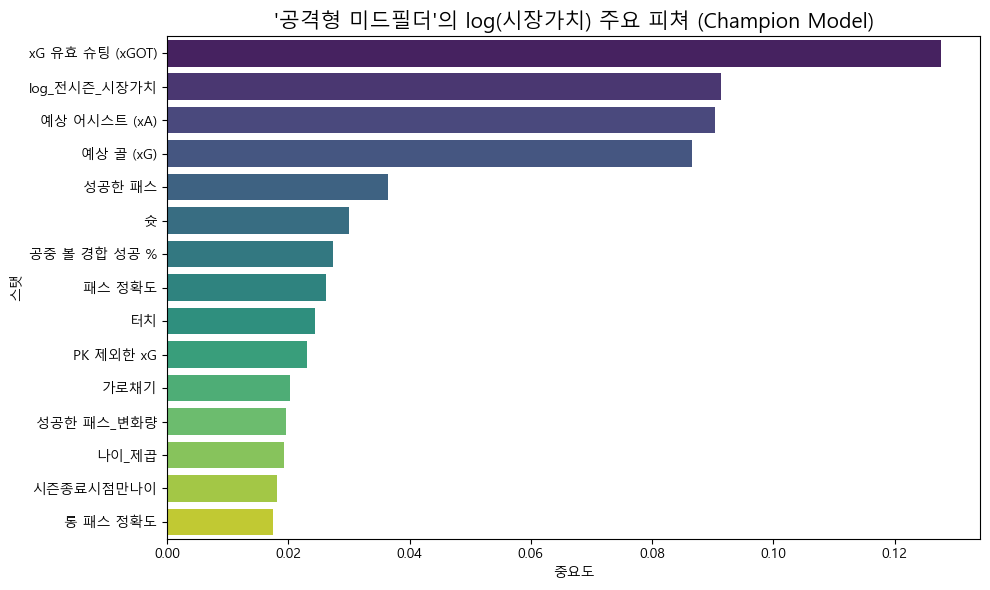

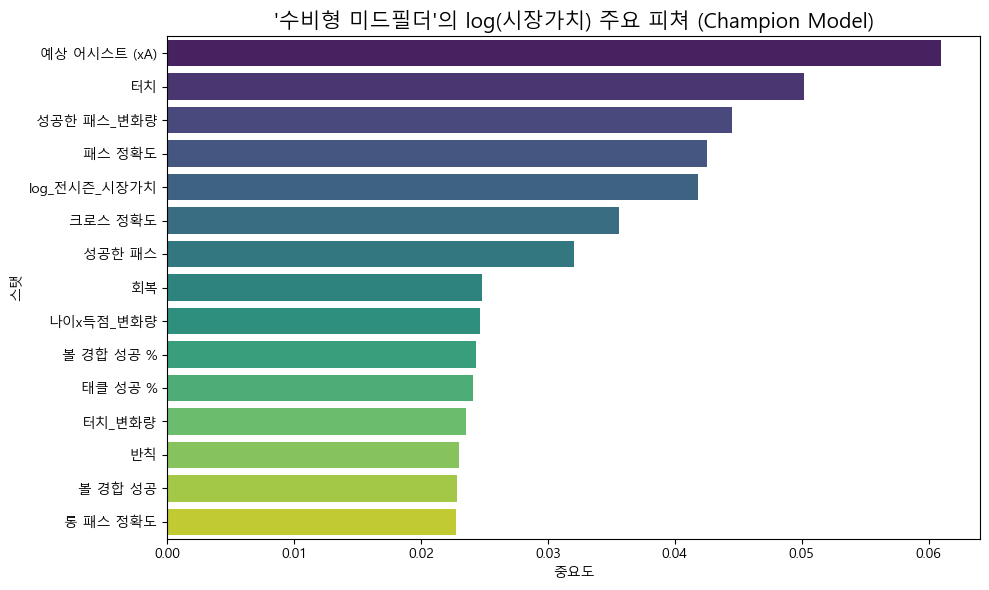

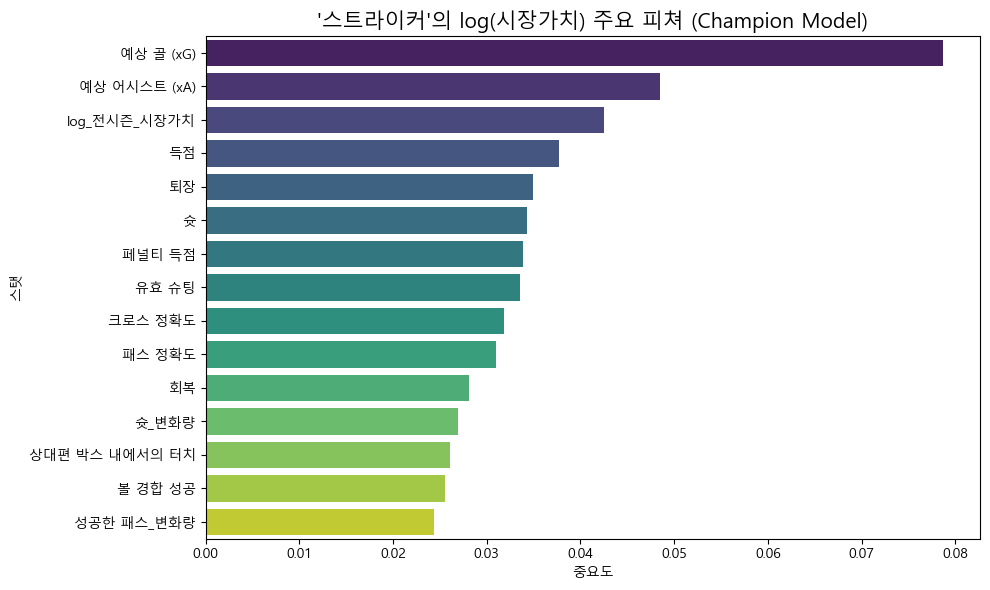

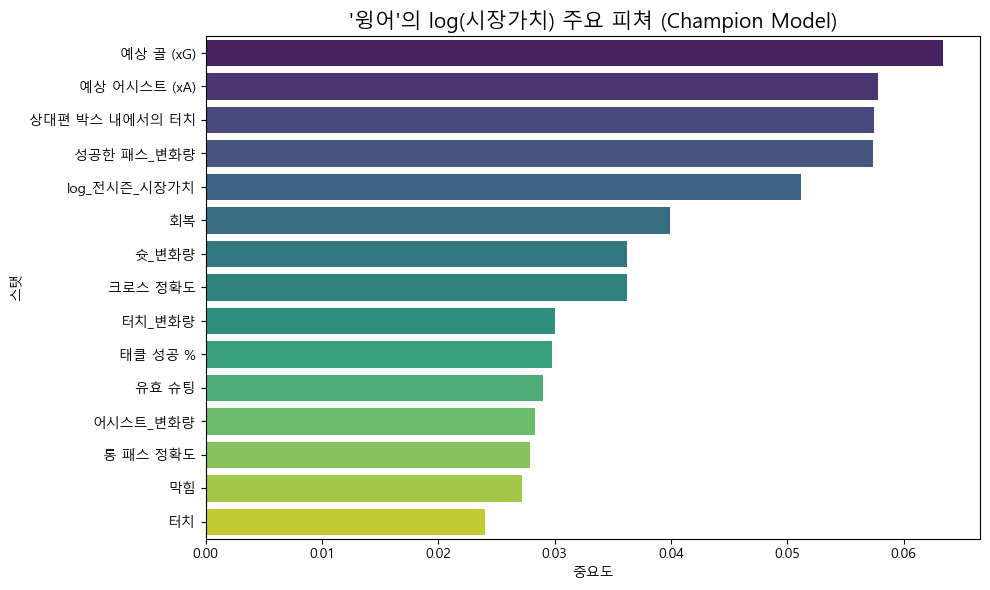

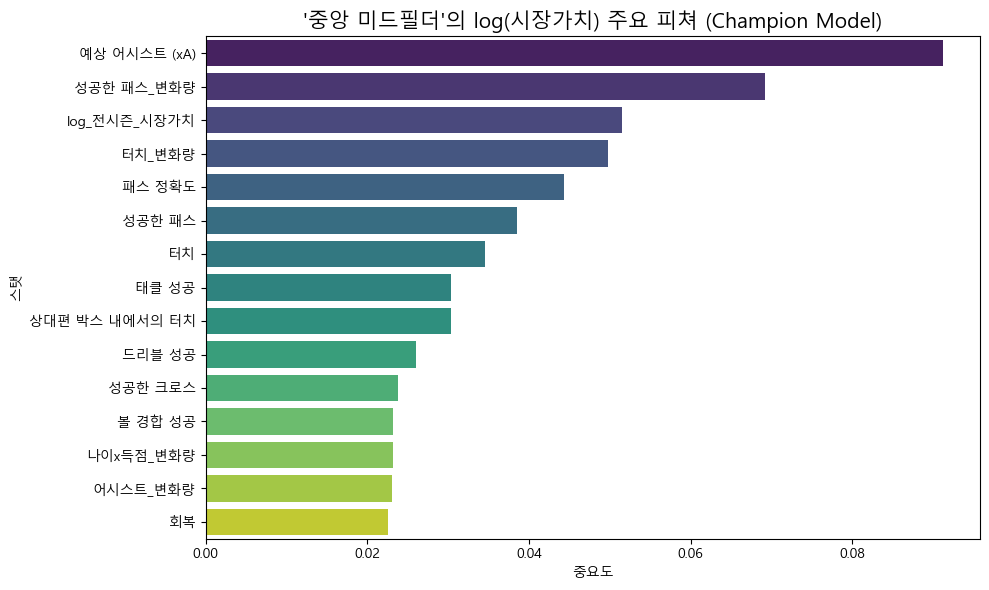

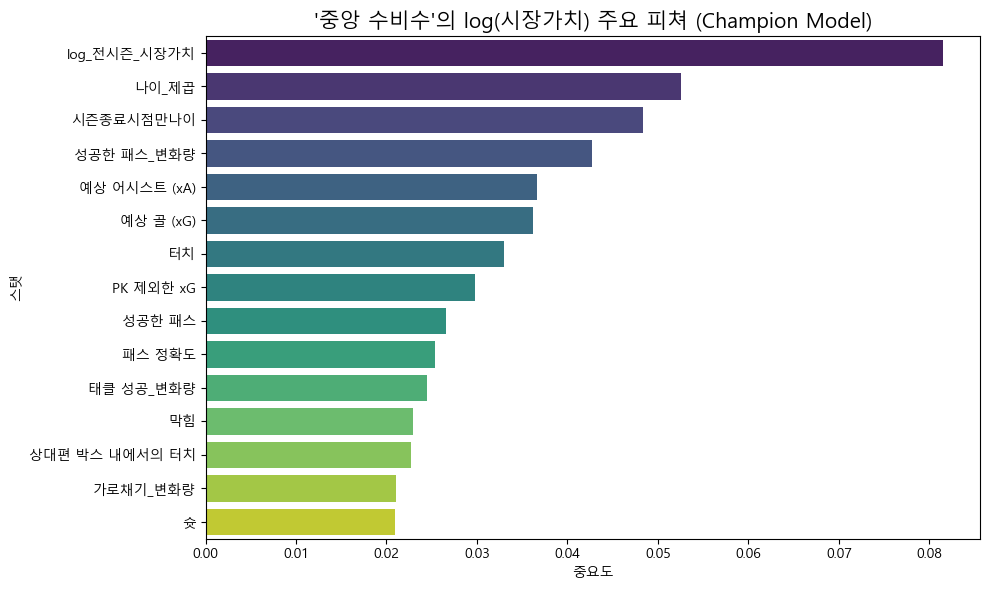

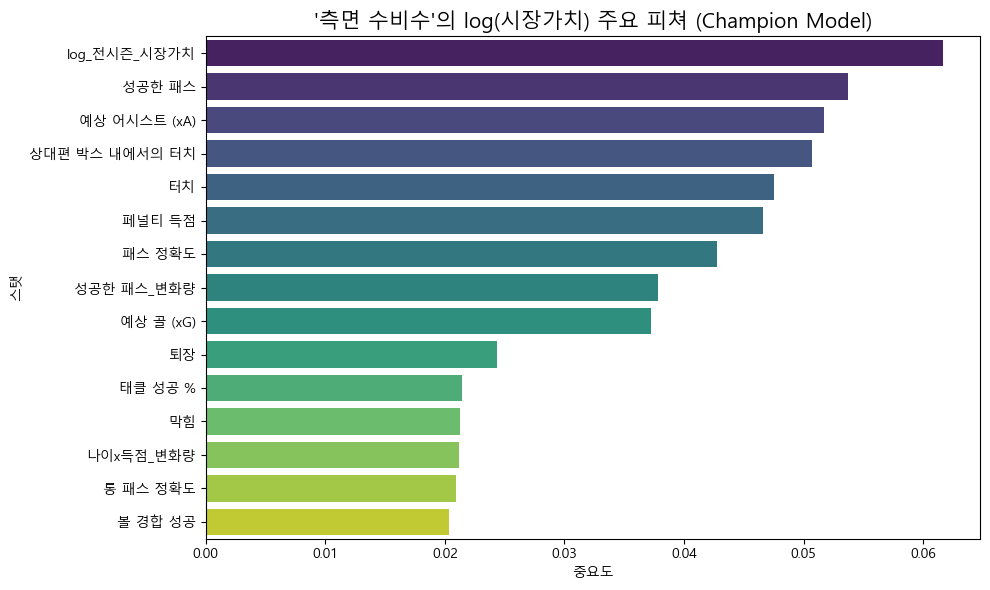

In [8]:
for group, results in results_storage.items():
    importances = results['model'].feature_importances_
    imp_df = pd.DataFrame(sorted(zip(importances, results['feature_names']), reverse=True), columns=['Importance', 'Feature']).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
    plt.title(f"'{group}'의 log(시장가치) 주요 피쳐 (Champion Model)", fontsize=15)
    plt.xlabel('중요도'); plt.ylabel('스탯'); plt.tight_layout()
    plt.show()

In [9]:
for group, results in results_storage.items():
    print("\n" + "*"*80)
    print(f"  예측 오차 심층 분석 - {group}")
    print("*"*80)
    
    # 오차 분석을 위한 데이터프레임 생성
    results_df = results['X_test'].copy()
    results_df['선수명'] = df.loc[results['X_test'].index, '선수명'] 
    results_df['전시즌_시장가치_EUR'] = df.loc[results['X_test'].index, '전시즌_시장가치_EUR']
    results_df['실제_시장가치_EUR'] = results['y_test_orig']
    results_df['예측_시장가치_EUR'] = pd.Series(results['y_pred'], index=results['X_test'].index)
    results_df['예측_오차_EUR'] = results_df['예측_시장가치_EUR'] - results_df['실제_시장가치_EUR']
    
    analysis_cols = ['선수명', '시즌종료시점만나이', '전시즌_시장가치_EUR', '실제_시장가치_EUR', '예측_시장가치_EUR', '예측_오차_EUR']
    error_analysis_df = results_df[analysis_cols].copy()

    # 결과 출력
    print("\n[⬆️ 모델이 가장 과대평가한 선수 TOP 5]")
    print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=False).head(5))
    
    print("\n[⬇️ 모델이 가장 과소평가한 선수 TOP 5]")
    print(error_analysis_df.sort_values(by='예측_오차_EUR', ascending=True).head(5))
    
    print("\n[🎯 모델이 가장 정확하게 예측한 선수 TOP 5]")
    most_accurate = error_analysis_df.copy()
    most_accurate['절대오차'] = most_accurate['예측_오차_EUR'].abs()
    print(most_accurate.sort_values(by='절대오차', ascending=True).head(5).drop(columns='절대오차'))


********************************************************************************
  예측 오차 심층 분석 - 공격형 미드필더
********************************************************************************

[⬆️ 모델이 가장 과대평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
4119         joao félix         24    67500000.0   33333333.0   67645464.0   
8206  philippe coutinho         29    63000000.0   19500000.0   46405180.0   
1435        enzo millot         20           0.0    4750000.0   28382016.0   
3769   giovani lo celso         27    45000000.0   18000000.0   38955704.0   
3274      marco asensio         25      100000.0   36666667.0   53982920.0   

       예측_오차_EUR  
4119  34312131.0  
8206  26905180.0  
1435  23632016.0  
3769  20955704.0  
3274  17316253.0  

[⬇️ 모델이 가장 과소평가한 선수 TOP 5]
                    선수명  시즌종료시점만나이  전시즌_시장가치_EUR  실제_시장가치_EUR  예측_시장가치_EUR  \
2810  philippe coutinho         26    42500000.0  120000000.0   50364180.0   
9253       paulo 

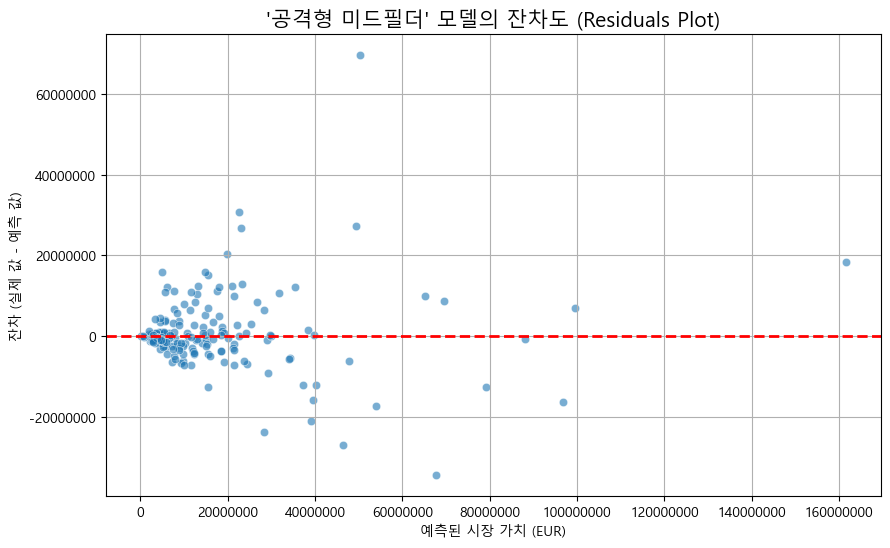

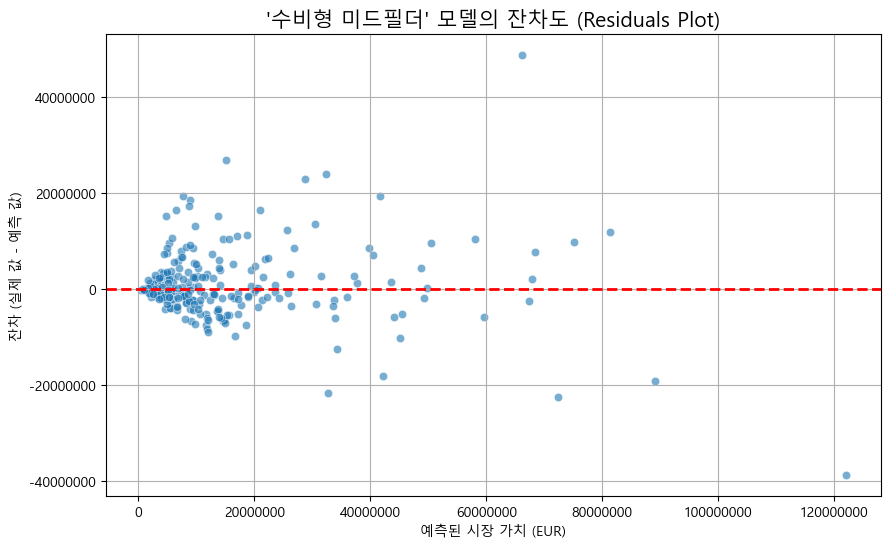

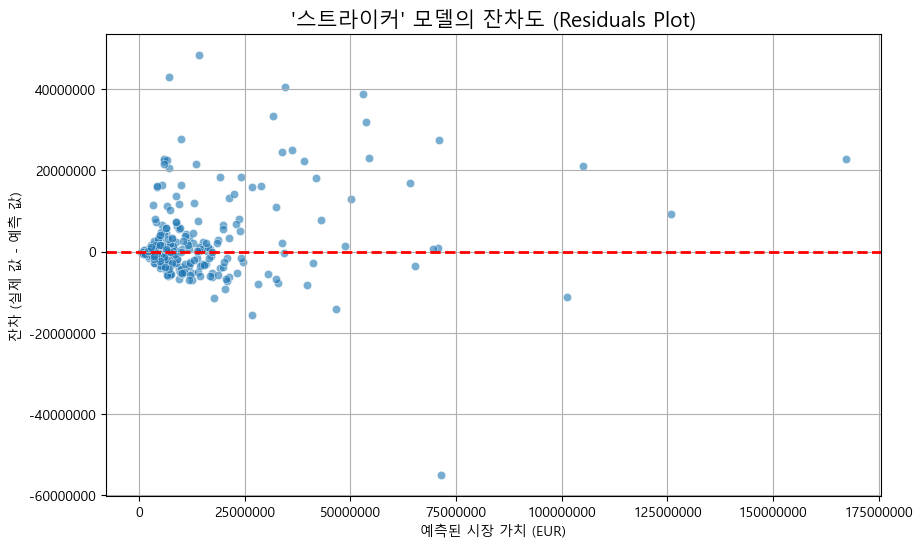

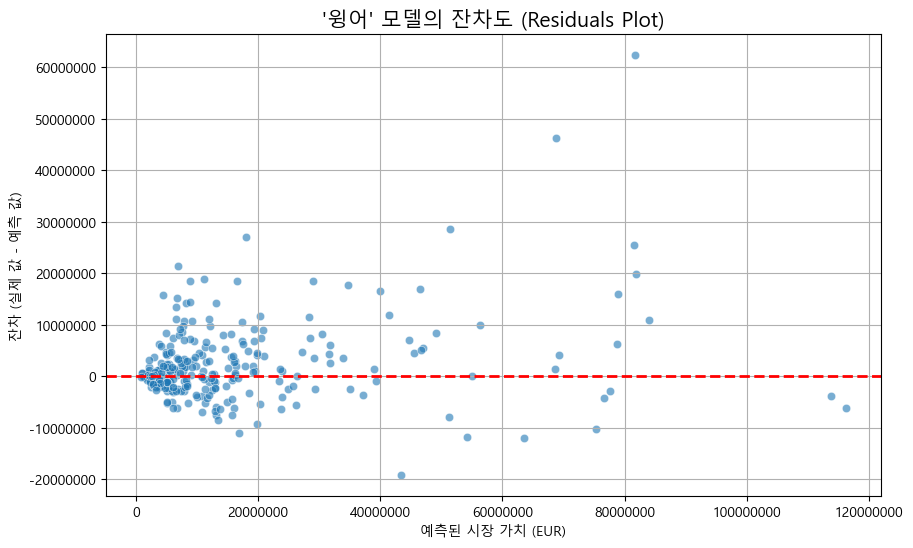

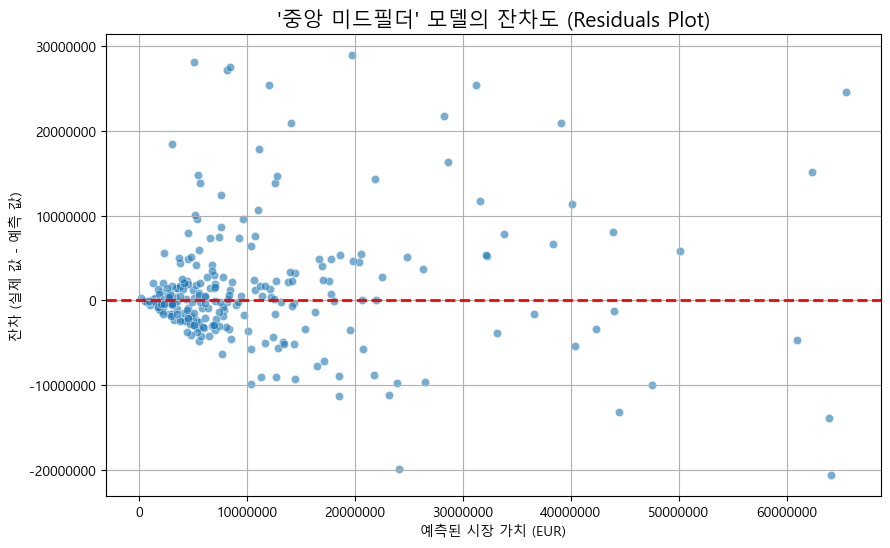

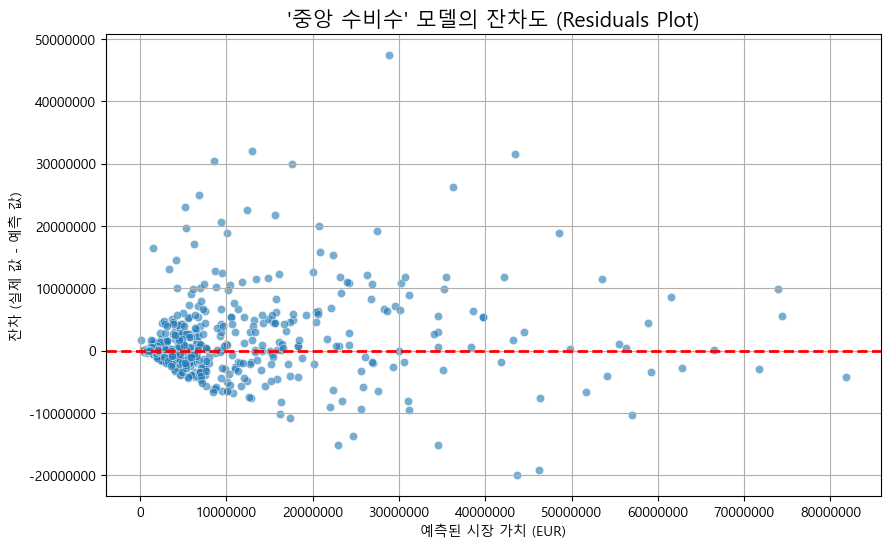

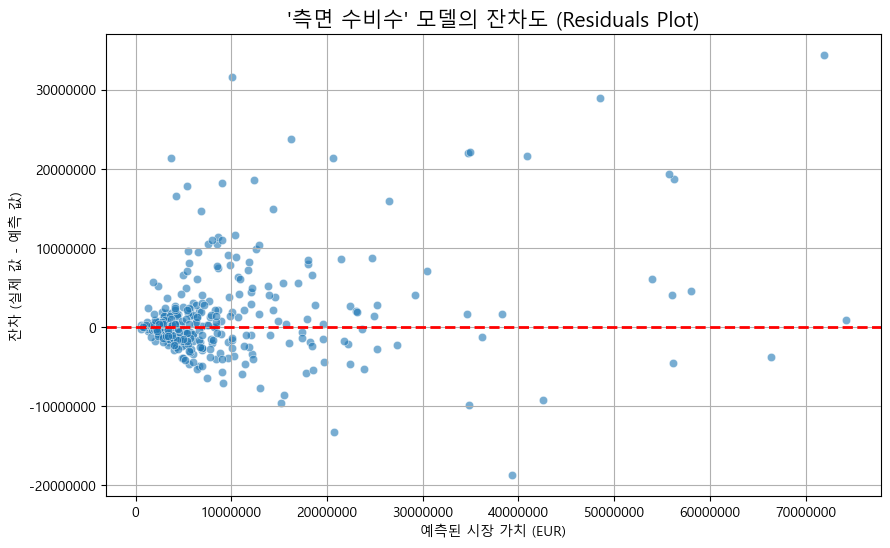

In [10]:
for group, results in results_storage.items():
    residuals = results['y_test_orig'] - results['y_pred']

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=results['y_pred'], y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title(f"'{group}' 모델의 잔차도 (Residuals Plot)", fontsize=15)
    plt.xlabel("예측된 시장 가치 (EUR)")
    plt.ylabel("잔차 (실제 값 - 예측 값)")
    plt.ticklabel_format(style='plain', axis='both')
    plt.grid(True)
    plt.show()

In [12]:
print("="*80)
print("각 피쳐의 통계적 유의성(p-value) 분석 (선형 회귀 모델)")
print("="*80)
print("p-value (P>|t|)가 0.05보다 낮으면, 해당 피쳐는 시장 가치에 통계적으로 유의미한 영향을 미친다고 해석할 수 있습니다.")

for group in position_groups:
    print("\n" + "-"*70)
    print(f"✨ 포지션 그룹 p-value 분석: {group} ✨")
    print("-" * 70)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: 
        print(f"'{group}' 그룹은 데이터 수가 적어 분석을 건너뜁니다.")
        continue

    # 1. 데이터 준비
    y = group_df['log_현재_시장가치']
    
    # 사용할 피쳐 선택 (XGBoost와 동일하게)
    cols_to_drop = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ] + [f'전시즌_{stat}' for stat in stats_for_change]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    # 2. 선형 회귀 모델은 스케일링을 하지 않은 원본 데이터로 분석하는 것이 일반적
    # statsmodels는 절편(intercept)을 위해 상수항을 직접 추가해줘야 함
    X_with_const = sm.add_constant(X)
    
    # 3. OLS(Ordinary Least Squares) 모델 학습 및 결과 출력
    # OLS는 가장 기본적인 선형 회귀 모델입니다.
    ols_model = sm.OLS(y, X_with_const)
    results = ols_model.fit()
    
    # 4. 결과 요약 테이블에서 p-value 확인
    # p-value가 낮은 상위 15개 피쳐만 필터링하여 출력
    p_values = results.pvalues.sort_values()
    
    print(f"\n[📊 {group} 모델의 주요 피쳐별 p-value (낮을수록 유의미)]")
    print(p_values.head(15))

각 피쳐의 통계적 유의성(p-value) 분석 (선형 회귀 모델)
p-value (P>|t|)가 0.05보다 낮으면, 해당 피쳐는 시장 가치에 통계적으로 유의미한 영향을 미친다고 해석할 수 있습니다.

----------------------------------------------------------------------
✨ 포지션 그룹 p-value 분석: 공격형 미드필더 ✨
----------------------------------------------------------------------

[📊 공격형 미드필더 모델의 주요 피쳐별 p-value (낮을수록 유의미)]
const              8.130085e-12
log_전시즌_시장가치       6.304276e-10
예상 어시스트 (xA)       1.080658e-06
PK 제외한 xG          1.167182e-06
나이_제곱              1.113718e-04
공중 볼 경합 성공         5.057971e-04
페널티 득점             5.254132e-04
슛                  1.018634e-03
드리블 성공             1.422478e-03
시즌종료시점만나이          1.940449e-03
태클 성공 %            2.135544e-03
xG 유효 슈팅 (xGOT)    6.117660e-03
성공한 패스             6.876334e-03
퇴장                 1.049835e-02
터치_변화량             2.011835e-02
dtype: float64

----------------------------------------------------------------------
✨ 포지션 그룹 p-value 분석: 수비형 미드필더 ✨
----------------------------------------------------------------------